In [1]:
import CubeGen.megaratools.megcubegen as mcube
import CubeGen.megaratools.megmapgen as mmap
import MapLines.tools.plot_tools as tol
from astropy.io import fits
import numpy as np

In [2]:
name=None
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC5-21AMEX/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-I'
reduxL2=['obsid12'+vph]

In [3]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing HATLASJ141727


In [4]:
savefile=False
basenameM='megMap-NAME.fits'
if savefile:
    mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)
else:
    mapt,hdr=mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameM)

Processing HATLASJ141727


In [5]:
name=hdr['OBJECT']+'_'+vph

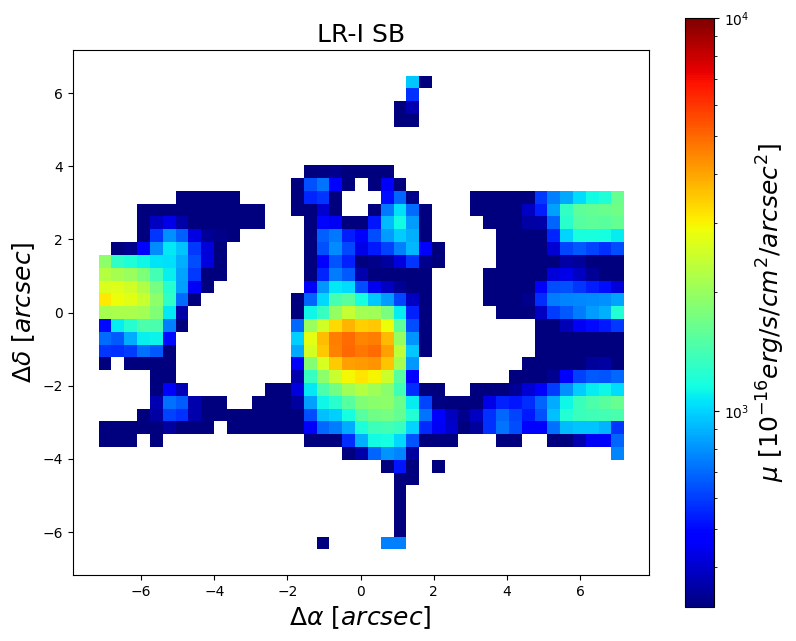

In [6]:
tol.get_plot(mapt,savef=True,pix=pix_s,name=name,
             tit='\mu',title=vph+' SB',cbtr=True,maxmin=[10**2.5,10**4.0],ewp=False)

In [7]:
[data,hdr]=fits.getdata(out_path+basenameC.replace('NAME',name)+'.gz', 0, header=True)

In [8]:
zt=0.22521176
nz,nx,ny=data.shape
crpix=hdr["CRPIX3"]
try:
    cdelt=hdr["CD3_3"]
except:
    cdelt=hdr["CDELT3"]
crval=hdr["CRVAL3"]
wave_f=crval+cdelt*(np.arange(nz)+1-crpix)
wave_f=wave_f/(1+zt)
ntw=np.where((wave_f > 6400) & (wave_f < 6600))[0]
flux=np.nanmean(data[ntw,:,:],axis=0)

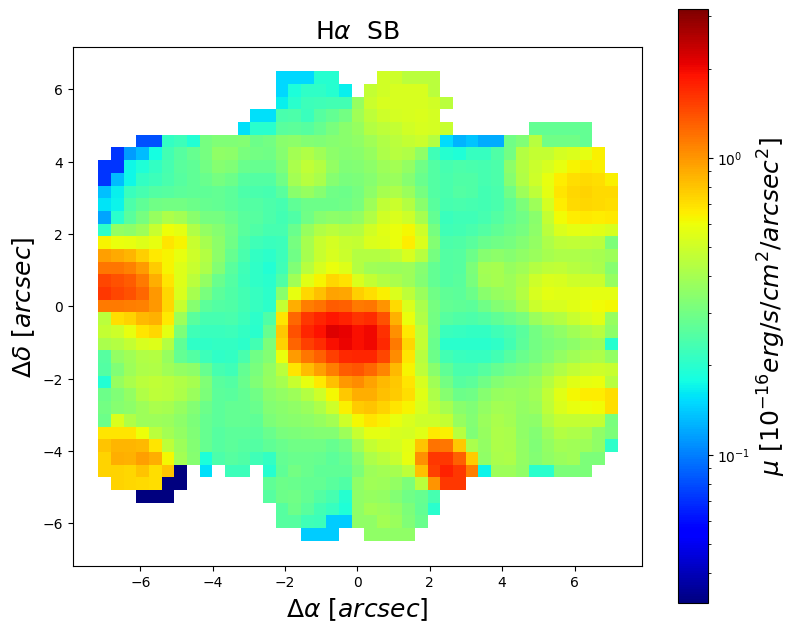

In [9]:
tol.get_plot(flux,savef=True,pix=pix_s,name=name+'Ha',
             tit='\mu',title=r'H$\alpha$  SB',cbtr=True,maxmin=[10**-1.5,10**0.5],ewp=False)